In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("pair_structure.csv")

# --- 1. Приведение числовых колонок ---
numeric_cols = ["QED", "SA", "MW", "LogP"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

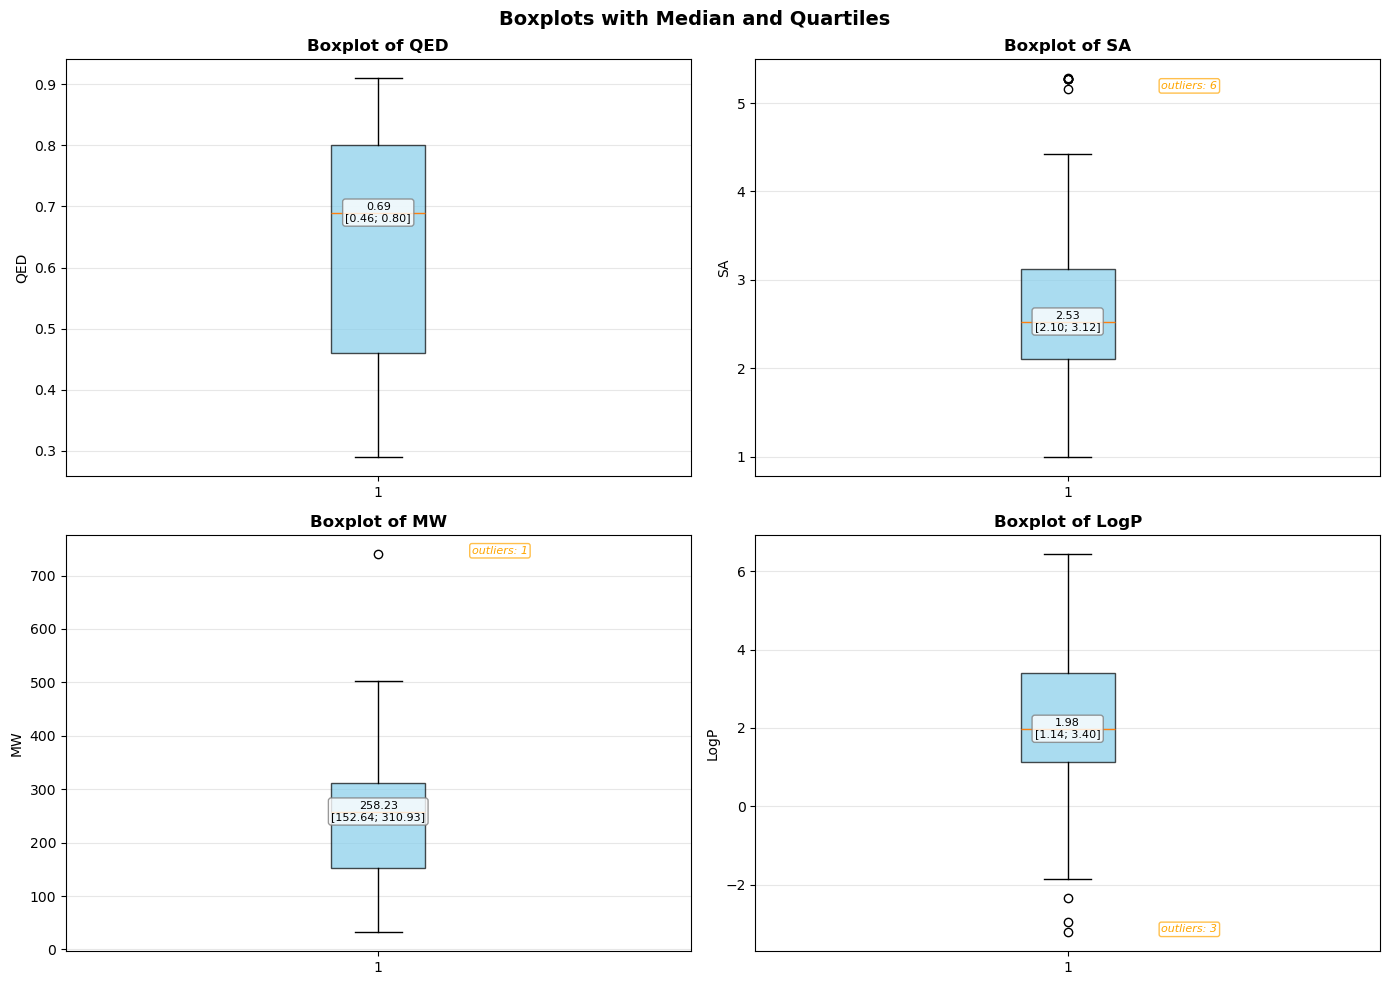

In [7]:
# ============================================
# 1. ВЕРТИКАЛЬНЫЕ BOXPLOT С ПОДПИСЯМИ
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # ВАЖНО: берём данные из колонки, а не саму колонку
    subset = df[col].values  # .values преобразует в numpy массив
    
    # Создаём boxplot
    bp = axes[i].boxplot(subset, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='skyblue', alpha=0.7))
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Расчёт статистик (используем исходные данные из DataFrame)
    data_series = df[col]
    q1 = data_series.quantile(0.25)
    median = data_series.quantile(0.5)
    q3 = data_series.quantile(0.75)
    
    # Позиция для подписи
    y = median
    x = 1
    
    # Добавляем подпись с рамкой
    axes[i].text(
        x,
        y,
        f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.8
        )
    )
    
    # Добавляем информацию о выбросах
    if len(bp['fliers']) > 0 and len(bp['fliers'][0].get_ydata()) > 0:
        outliers = bp['fliers'][0].get_ydata()
        axes[i].text(
            x + 0.15, 
            outliers[0],
            f'outliers: {len(outliers)}', 
            fontsize=8, 
            color='orange', 
            style='italic',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="orange",
                alpha=0.7
            )
        )

plt.suptitle('Boxplots with Median and Quartiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

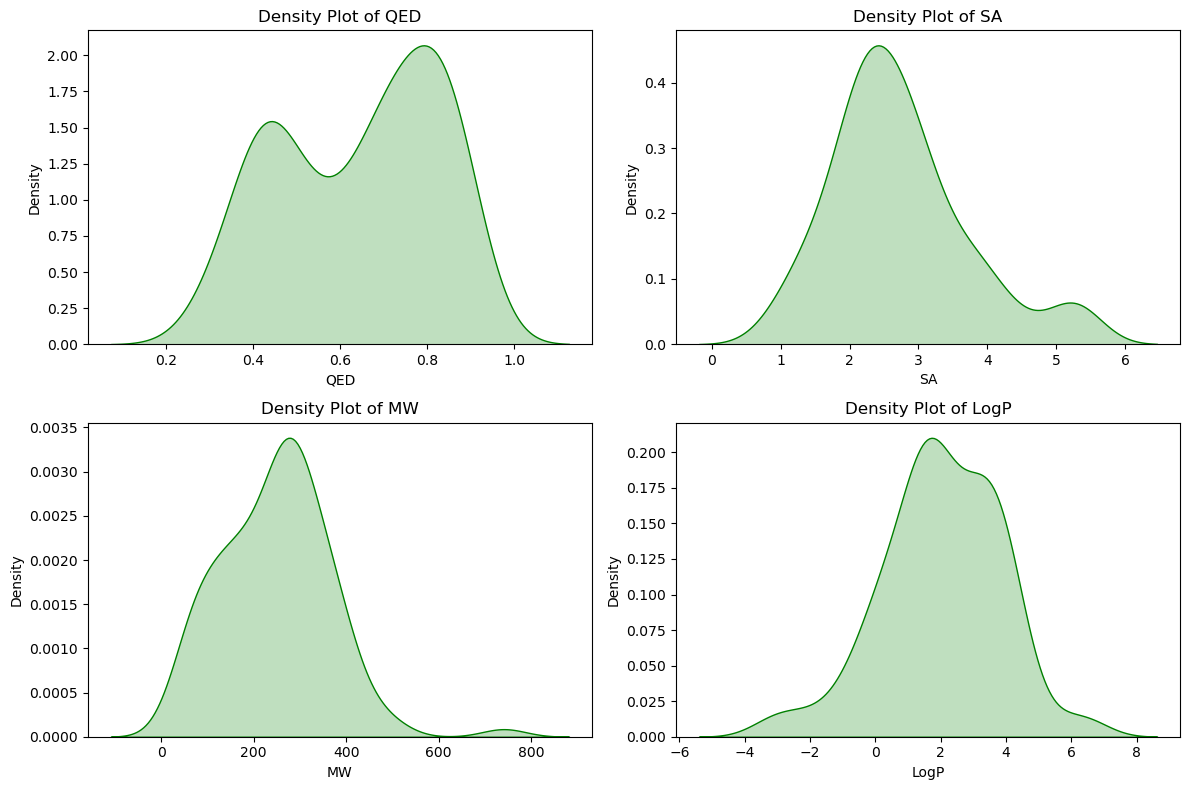

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(df[col], fill=True, ax=axes[i], color='green')
    axes[i].set_title(f'Density Plot of {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()


1. СРАВНЕНИЕ: very bad bro, bad bro, good bro

QED:
  very bad bro: медиана=0.42, Q1=0.39, Q3=0.43, n=4
  bad bro: медиана=0.48, Q1=0.45, Q3=0.72, n=23
  good bro: медиана=0.60, Q1=0.41, Q3=0.74, n=19

SA:
  very bad bro: медиана=2.84, Q1=2.25, Q3=3.21, n=4
  bad bro: медиана=2.53, Q1=2.12, Q3=2.88, n=23
  good bro: медиана=2.13, Q1=1.66, Q3=2.56, n=19

MW:
  very bad bro: медиана=113.76, Q1=95.12, Q3=162.35, n=4
  bad bro: медиана=164.16, Q1=90.62, Q3=260.72, n=23
  good bro: медиана=176.22, Q1=130.12, Q3=265.31, n=19

LogP:
  very bad bro: медиана=1.48, Q1=0.82, Q3=2.31, n=4
  bad bro: медиана=1.42, Q1=0.13, Q3=2.18, n=23
  good bro: медиана=1.35, Q1=-0.48, Q3=2.08, n=19


C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3902615425.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3902615425.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3902615425.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3902615425.py:36: MatplotlibDe

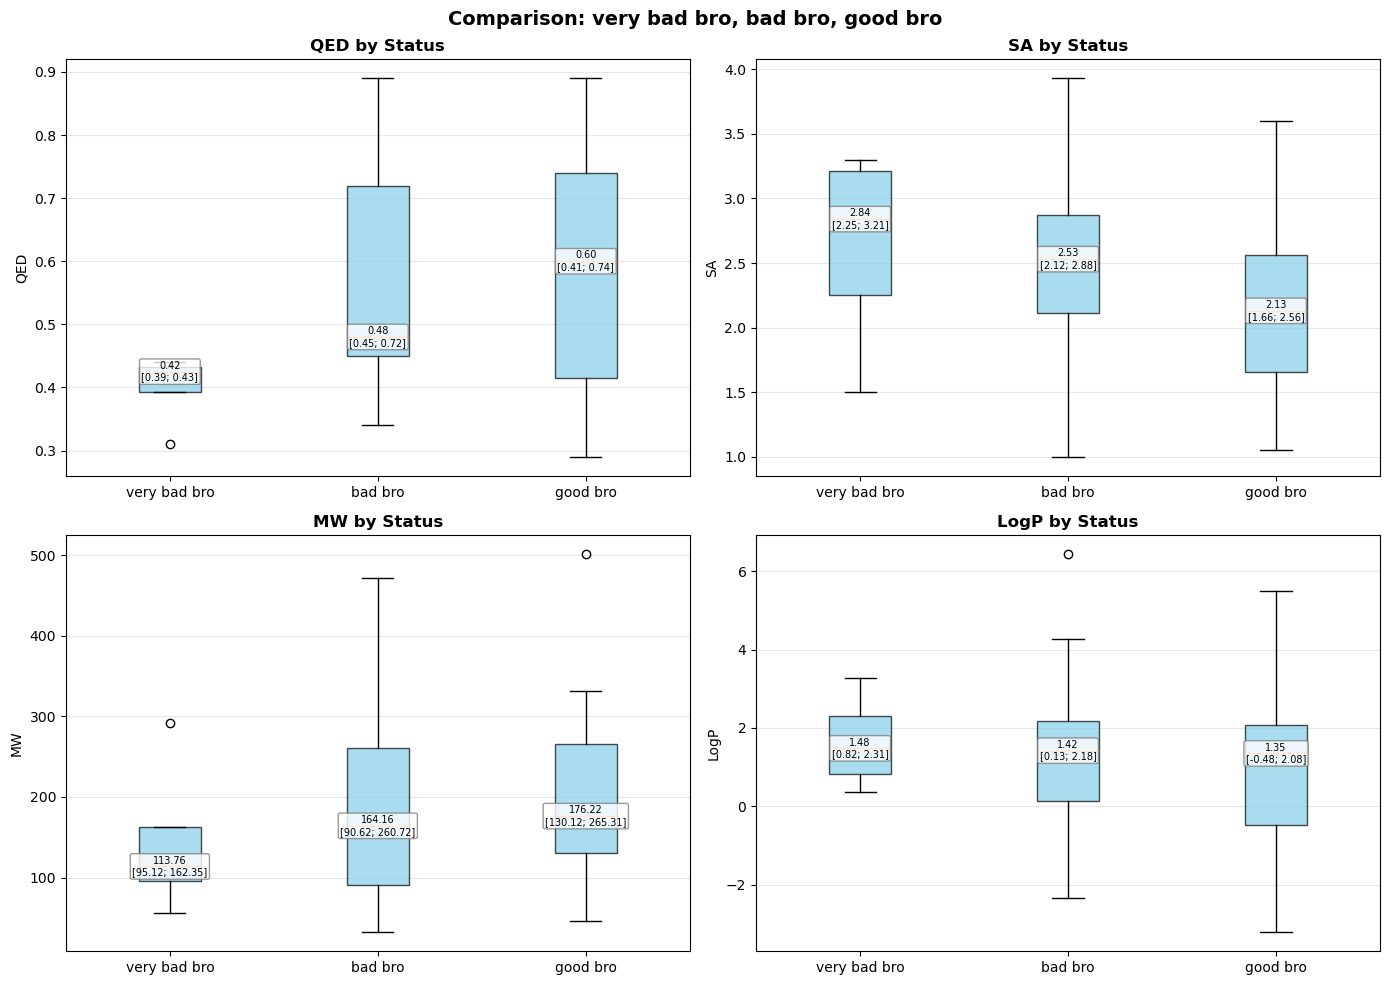

In [13]:
# ============================================
# 1. СРАВНЕНИЕ ПО КАТЕГОРИЯМ: very bad bro, bad bro, good bro
# ============================================

# Категории для сравнения
categories_1 = ['very bad bro', 'bad bro', 'good bro']
df_cat1 = df[df['Status'].isin(categories_1)]

print("\n" + "="*70)
print("1. СРАВНЕНИЕ: very bad bro, bad bro, good bro")
print("="*70)
for col in numeric_cols:
    print(f"\n{col}:")
    for cat in categories_1:
        subset = df_cat1[df_cat1['Status'] == cat][col]
        if len(subset) > 0:
            print(f"  {cat}: медиана={subset.median():.2f}, Q1={subset.quantile(0.25):.2f}, Q3={subset.quantile(0.75):.2f}, n={len(subset)}")
        else:
            print(f"  {cat}: нет данных")

# Boxplot для категорий 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Подготовка данных
    data_to_plot = []
    labels = []
    for cat in categories_1:
        subset = df_cat1[df_cat1['Status'] == cat][col].values
        if len(subset) > 0:
            data_to_plot.append(subset)
            labels.append(cat)
    
    if data_to_plot:
        bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
                              boxprops=dict(facecolor='skyblue', alpha=0.7))
        axes[i].set_title(f'{col} by Status', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Добавляем подписи с медианой и квартилями
        for j, cat in enumerate([c for c in categories_1 if len(df_cat1[df_cat1['Status'] == c][col]) > 0], start=1):
            subset = df_cat1[df_cat1['Status'] == cat][col]
            q1 = subset.quantile(0.25)
            median = subset.quantile(0.5)
            q3 = subset.quantile(0.75)
            
            axes[i].text(
                j,
                median,
                f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
                ha="center",
                va="center",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
            )

plt.suptitle('Comparison: very bad bro, bad bro, good bro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

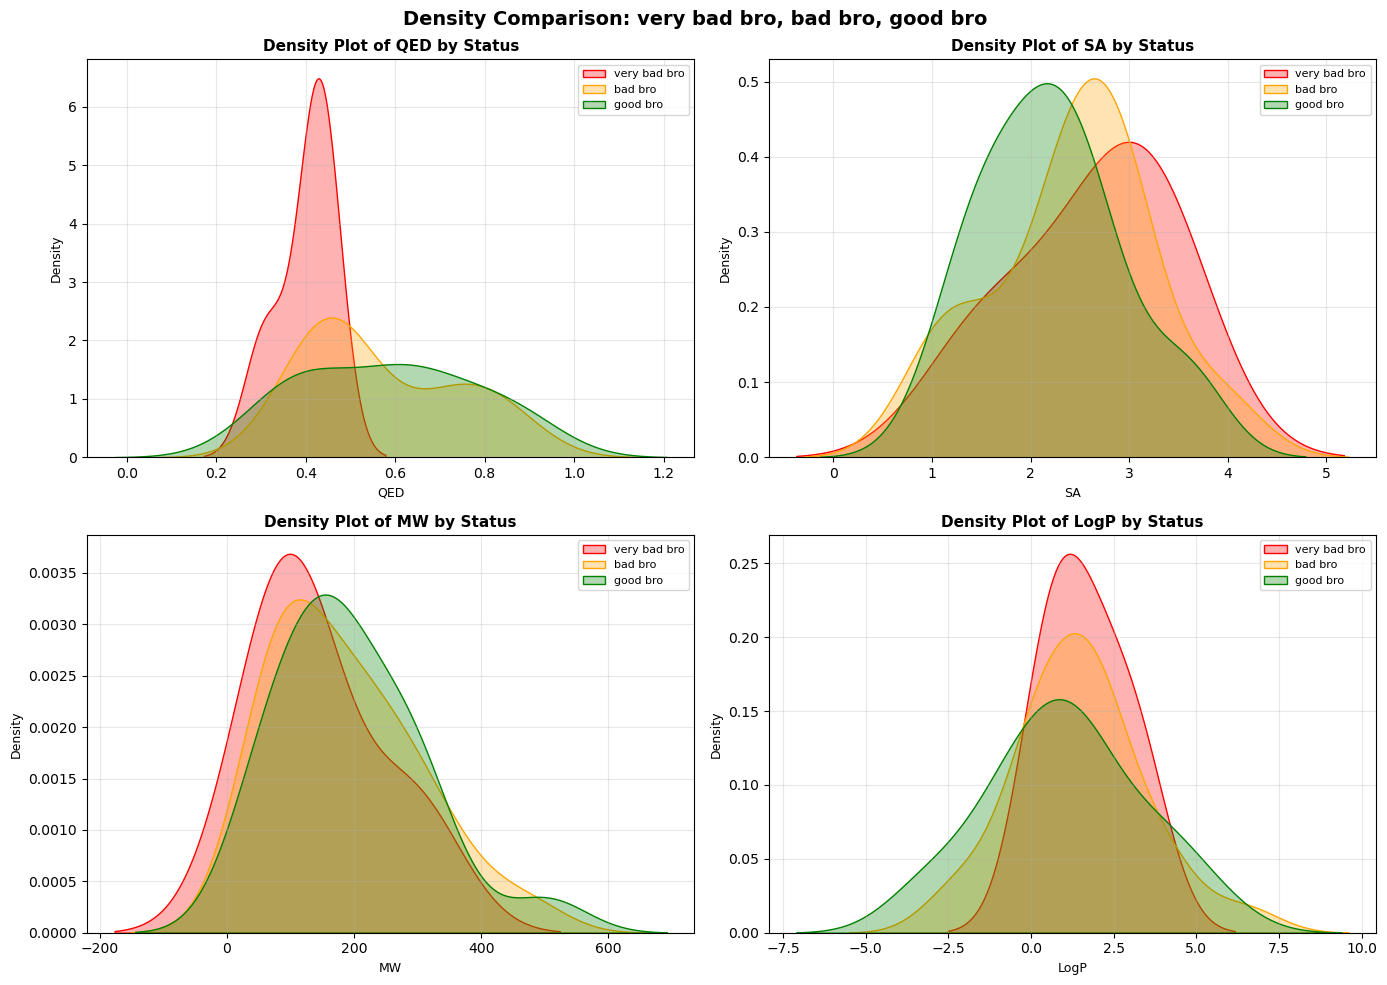

In [15]:
# Density plot для категорий 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'very bad bro': 'red', 'bad bro': 'orange', 'good bro': 'green'}

for i, col in enumerate(numeric_cols):
    for cat in categories_1:
        subset = df_cat1[df_cat1['Status'] == cat][col].dropna()
        if len(subset) > 0:
            sns.kdeplot(subset, label=cat, fill=True, alpha=0.3, 
                       color=colors.get(cat, 'blue'), ax=axes[i])
    axes[i].set_title(f'Density Plot of {col} by Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Density Comparison: very bad bro, bad bro, good bro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


2. СРАВНЕНИЕ: more active bro, less active bro

QED:
  more active bro: медиана=0.78, Q1=0.70, Q3=0.85, n=14
  less active bro: медиана=0.81, Q1=0.73, Q3=0.85, n=14

SA:
  more active bro: медиана=2.67, Q1=2.24, Q3=3.33, n=14
  less active bro: медиана=2.55, Q1=2.16, Q3=3.06, n=14

MW:
  more active bro: медиана=287.36, Q1=238.87, Q3=340.17, n=14
  less active bro: медиана=282.88, Q1=238.87, Q3=320.66, n=14

LogP:
  more active bro: медиана=3.09, Q1=2.42, Q3=3.59, n=14
  less active bro: медиана=3.09, Q1=2.12, Q3=3.65, n=14


C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3925544171.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3925544171.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3925544171.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\3925544171.py:34: MatplotlibDe

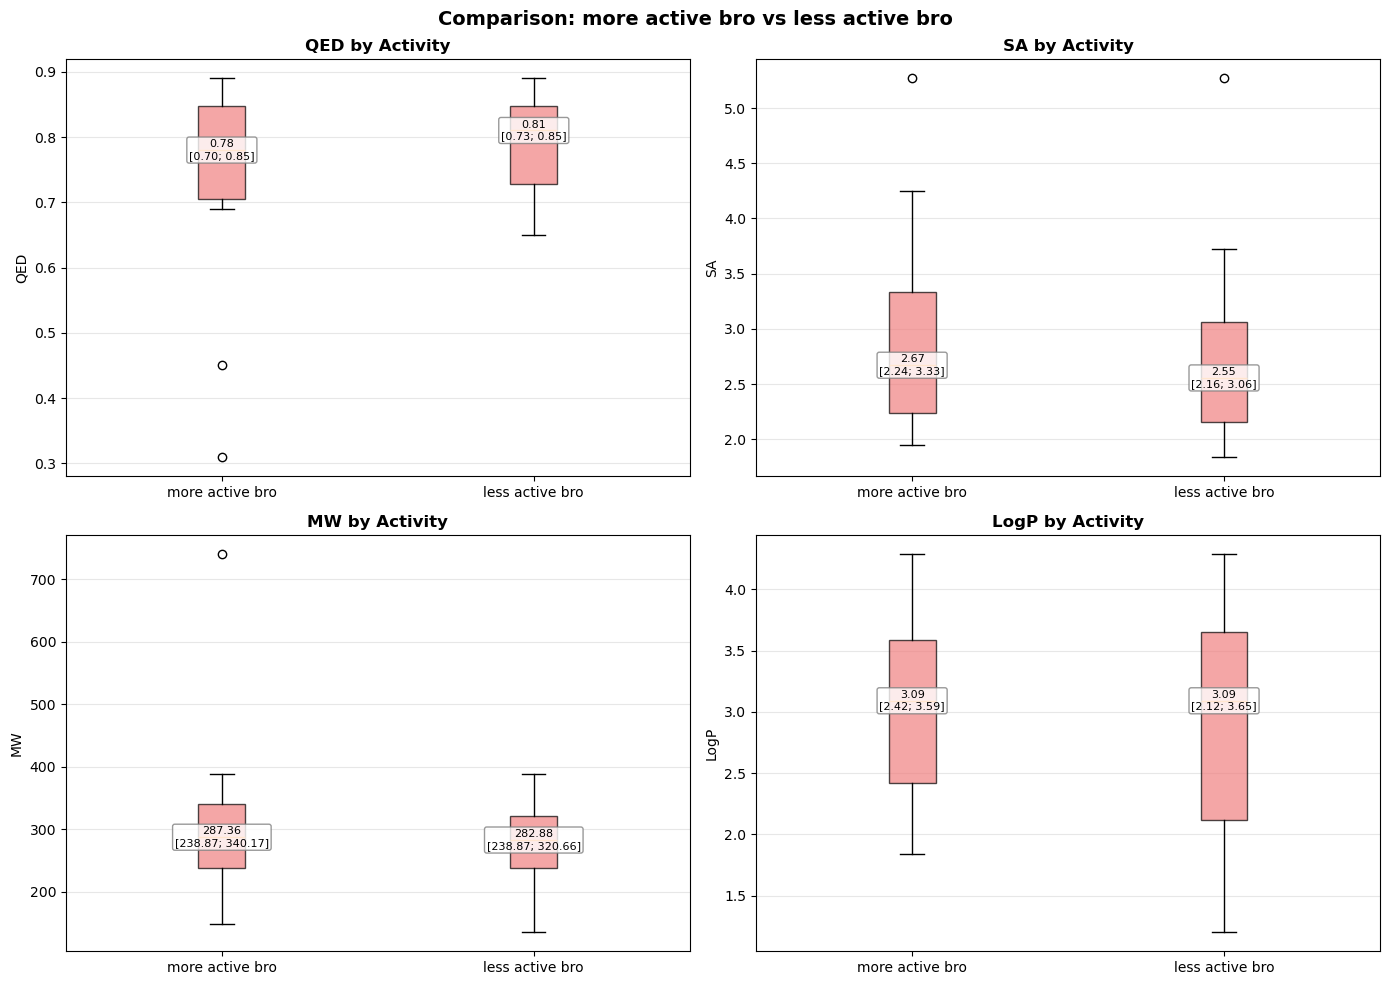

In [17]:
# ============================================
# 2. СРАВНЕНИЕ ПО КАТЕГОРИЯМ: more active bro, less active bro
# ============================================

categories_2 = ['more active bro', 'less active bro']
df_cat2 = df[df['Status'].isin(categories_2)]

print("\n" + "="*70)
print("2. СРАВНЕНИЕ: more active bro, less active bro")
print("="*70)
for col in numeric_cols:
    print(f"\n{col}:")
    for cat in categories_2:
        subset = df_cat2[df_cat2['Status'] == cat][col]
        if len(subset) > 0:
            print(f"  {cat}: медиана={subset.median():.2f}, Q1={subset.quantile(0.25):.2f}, Q3={subset.quantile(0.75):.2f}, n={len(subset)}")
        else:
            print(f"  {cat}: нет данных")

# Boxplot для категорий 2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_to_plot = []
    labels = []
    for cat in categories_2:
        subset = df_cat2[df_cat2['Status'] == cat][col].values
        if len(subset) > 0:
            data_to_plot.append(subset)
            labels.append(cat)
    
    if data_to_plot:
        bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
                              boxprops=dict(facecolor='lightcoral', alpha=0.7))
        axes[i].set_title(f'{col} by Activity', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        for j, cat in enumerate(categories_2, start=1):
            if len(df_cat2[df_cat2['Status'] == cat][col]) > 0:
                subset = df_cat2[df_cat2['Status'] == cat][col]
                q1 = subset.quantile(0.25)
                median = subset.quantile(0.5)
                q3 = subset.quantile(0.75)
                
                axes[i].text(
                    j,
                    median,
                    f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
                    ha="center",
                    va="center",
                    fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
                )

plt.suptitle('Comparison: more active bro vs less active bro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

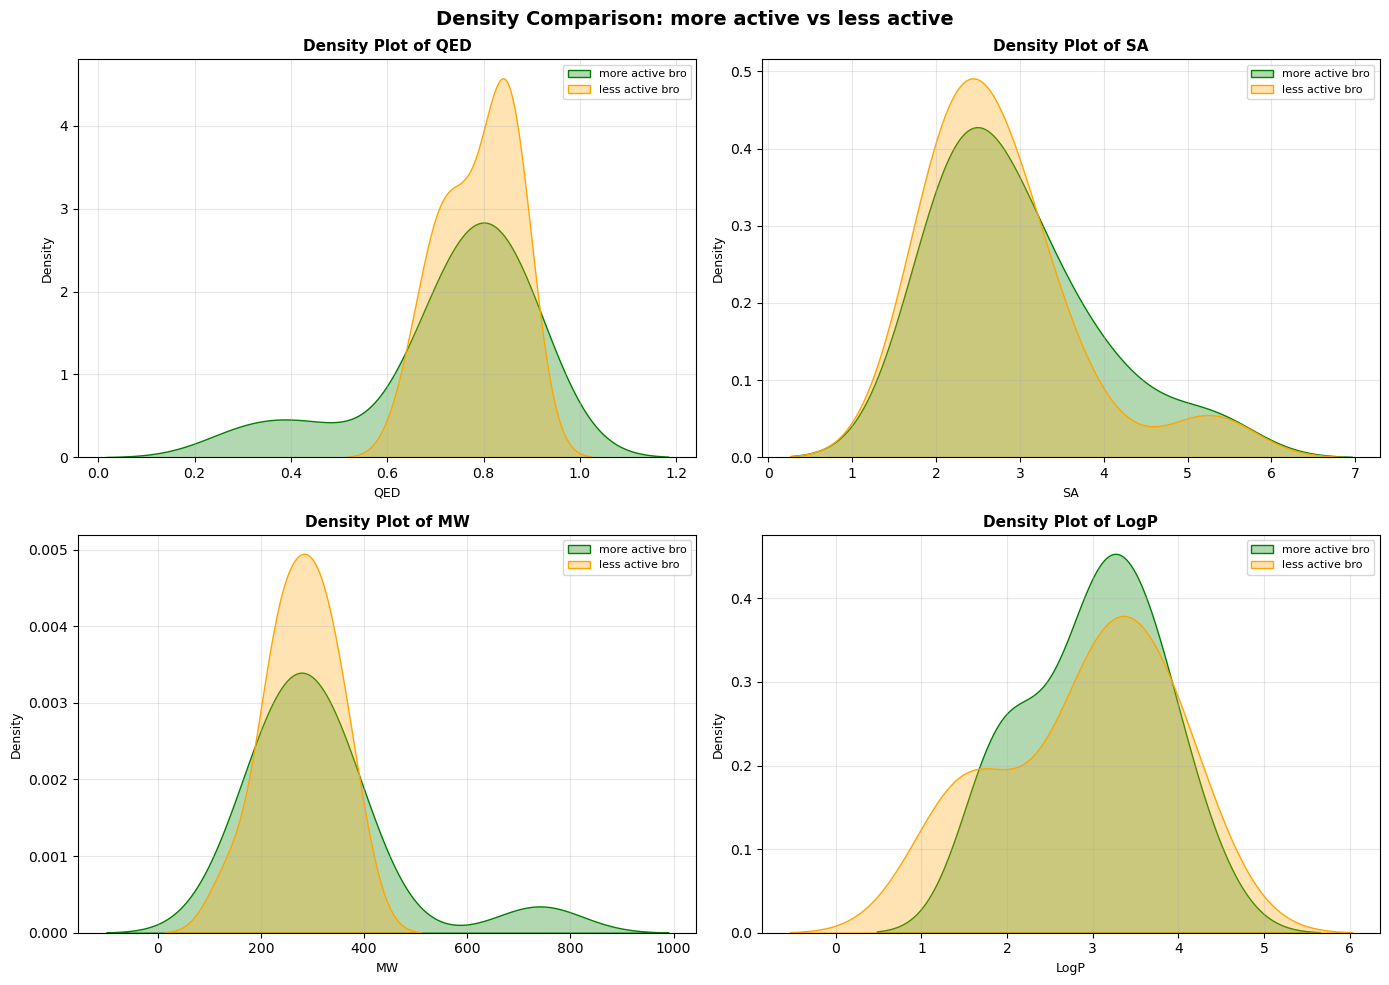

In [19]:
# Density plot для категорий 2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors_2 = {'more active bro': 'green', 'less active bro': 'orange'}

for i, col in enumerate(numeric_cols):
    for cat in categories_2:
        subset = df_cat2[df_cat2['Status'] == cat][col].dropna()
        if len(subset) > 0:
            sns.kdeplot(subset, label=cat, fill=True, alpha=0.3,
                       color=colors_2.get(cat, 'blue'), ax=axes[i])
    axes[i].set_title(f'Density Plot of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Density Comparison: more active vs less active', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


3. СРАВНЕНИЕ: pro-drug, active metabolite

QED:
  pro-drug: медиана=0.67, Q1=0.49, Q3=0.79, n=12
  active metabolite: медиана=0.69, Q1=0.54, Q3=0.81, n=13

SA:
  pro-drug: медиана=3.04, Q1=2.43, Q3=4.05, n=12
  active metabolite: медиана=3.16, Q1=2.16, Q3=3.90, n=13

MW:
  pro-drug: медиана=335.42, Q1=282.92, Q3=381.94, n=12
  active metabolite: медиана=284.36, Q1=249.35, Q3=327.38, n=13

LogP:
  pro-drug: медиана=2.31, Q1=1.58, Q3=3.82, n=12
  active metabolite: медиана=1.56, Q1=0.81, Q3=3.13, n=13


C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\2456784361.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\2456784361.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\2456784361.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_9572\2456784361.py:34: MatplotlibDe

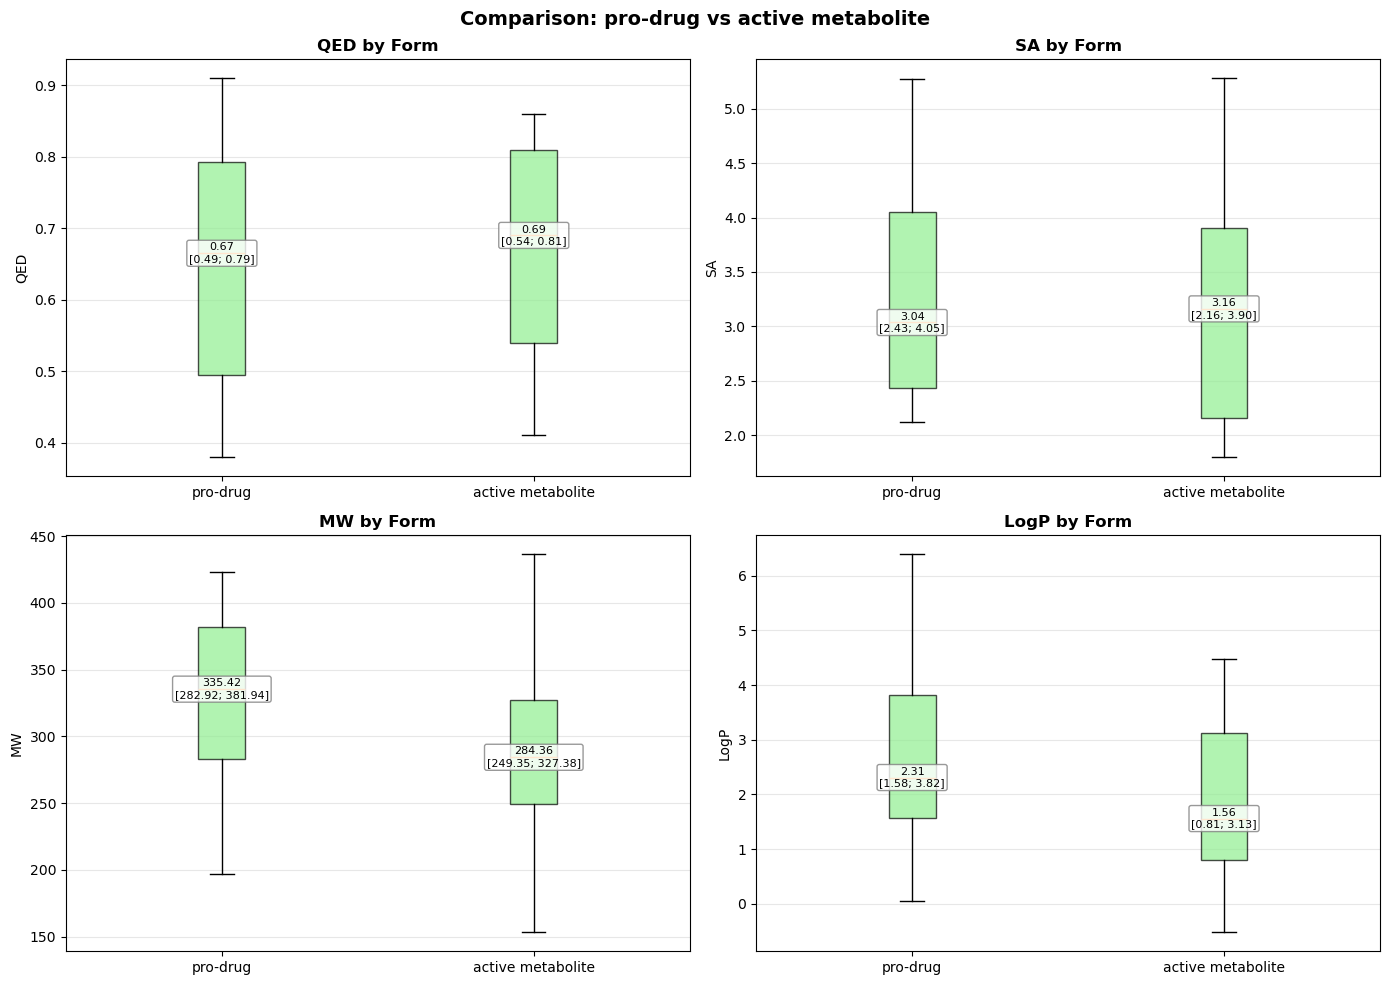

In [21]:
# ============================================
# 3. СРАВНЕНИЕ ПО КАТЕГОРИЯМ: pro-drug, active metabolite
# ============================================

categories_3 = ['pro-drug', 'active metabolite']
df_cat3 = df[df['Status'].isin(categories_3)]

print("\n" + "="*70)
print("3. СРАВНЕНИЕ: pro-drug, active metabolite")
print("="*70)
for col in numeric_cols:
    print(f"\n{col}:")
    for cat in categories_3:
        subset = df_cat3[df_cat3['Status'] == cat][col]
        if len(subset) > 0:
            print(f"  {cat}: медиана={subset.median():.2f}, Q1={subset.quantile(0.25):.2f}, Q3={subset.quantile(0.75):.2f}, n={len(subset)}")
        else:
            print(f"  {cat}: нет данных")

# Boxplot для категорий 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_to_plot = []
    labels = []
    for cat in categories_3:
        subset = df_cat3[df_cat3['Status'] == cat][col].values
        if len(subset) > 0:
            data_to_plot.append(subset)
            labels.append(cat)
    
    if data_to_plot:
        bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
                              boxprops=dict(facecolor='lightgreen', alpha=0.7))
        axes[i].set_title(f'{col} by Form', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        for j, cat in enumerate(categories_3, start=1):
            if len(df_cat3[df_cat3['Status'] == cat][col]) > 0:
                subset = df_cat3[df_cat3['Status'] == cat][col]
                q1 = subset.quantile(0.25)
                median = subset.quantile(0.5)
                q3 = subset.quantile(0.75)
                
                axes[i].text(
                    j,
                    median,
                    f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
                    ha="center",
                    va="center",
                    fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
                )

plt.suptitle('Comparison: pro-drug vs active metabolite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

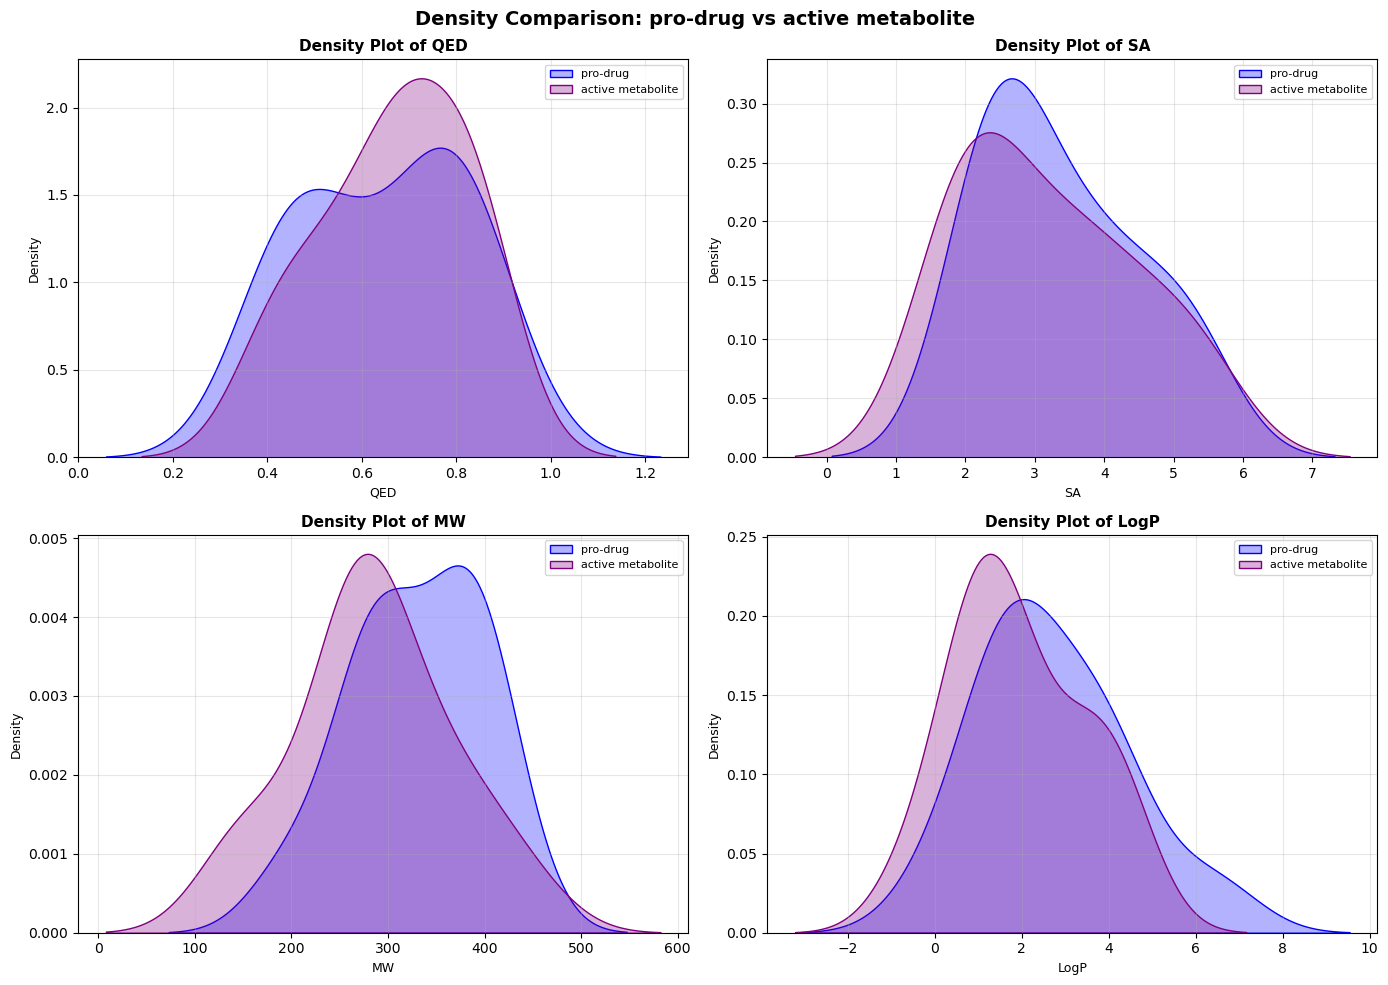

In [23]:
# Density plot для категорий 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors_3 = {'pro-drug': 'blue', 'active metabolite': 'purple'}

for i, col in enumerate(numeric_cols):
    for cat in categories_3:
        subset = df_cat3[df_cat3['Status'] == cat][col].dropna()
        if len(subset) > 0:
            sns.kdeplot(subset, label=cat, fill=True, alpha=0.3,
                       color=colors_3.get(cat, 'blue'), ax=axes[i])
    axes[i].set_title(f'Density Plot of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Density Comparison: pro-drug vs active metabolite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()